<a href="https://colab.research.google.com/github/anyelakaterine/Proyecto-inteligencia-artificial./blob/main/TP/algoritmo_%20A*.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

{'B': 'A', 'C': 'A', 'D': 'B', 'E': 'B', 'F': 'E'}
El camino encontrado es:
A -> B -> E -> F


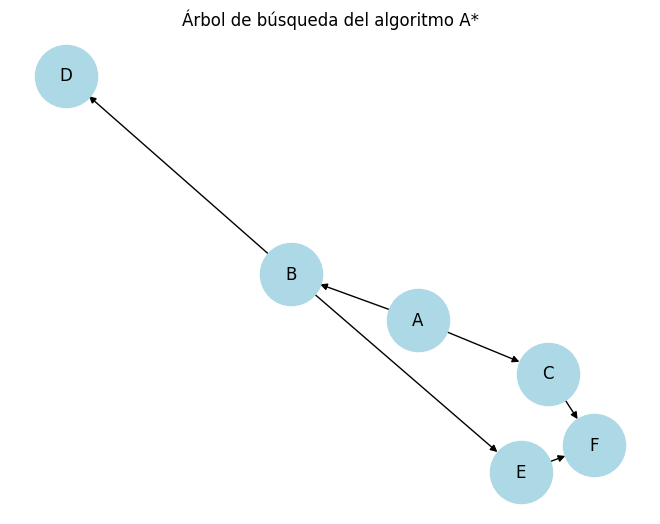

In [1]:
# Importamos heapq que nos permite usar una cola de prioridad
import heapq

# Definimos la función del algoritmo A*
def algoritmo_a_estrella(grafo, inicio, objetivo, heuristica):

    # Lista de nodos abiertos (cola de prioridad)
    abiertos = []

    # Insertamos el nodo inicial con prioridad 0
    heapq.heappush(abiertos, (0, inicio))

    # Diccionario para reconstruir el camino
    camino = {}

    # Diccionario para guardar el costo desde el inicio
    costo_g = {inicio: 0}

    # Mientras haya nodos por explorar
    while abiertos:

        # Extraemos el nodo con menor costo
        actual = heapq.heappop(abiertos)[1]

        # Si llegamos al objetivo terminamos
        if actual == objetivo:
            break

        # Revisamos los vecinos del nodo actual
        for vecino, costo in grafo[actual]:

            # Calculamos el nuevo costo
            nuevo_costo = costo_g[actual] + costo

            # Si el nodo no ha sido visitado o encontramos un camino mejor
            if vecino not in costo_g or nuevo_costo < costo_g[vecino]:

                # Guardamos el costo
                costo_g[vecino] = nuevo_costo

                # Calculamos la prioridad usando la heurística
                prioridad = nuevo_costo + heuristica[vecino]

                # Agregamos el nodo a la cola de prioridad
                heapq.heappush(abiertos, (prioridad, vecino))

                # Guardamos de dónde viene el nodo
                camino[vecino] = actual

    return camino

    # Definimos el grafo usando un diccionario
grafo = {
    'A': [('B',1), ('C',3)],
    'B': [('D',3), ('E',1)],
    'C': [('F',5)],
    'D': [],
    'E': [('F',1)],
    'F': []
}

# Definimos la heurística estimada hacia el objetivo
heuristica = {
    'A':5,
    'B':4,
    'C':2,
    'D':3,
    'E':1,
    'F':0
}

# Nodo inicial
inicio = 'A'

# Nodo objetivo
objetivo = 'F'

# Ejecutamos el algoritmo
camino = algoritmo_a_estrella(grafo, inicio, objetivo, heuristica)

print(camino)

# Función para reconstruir el camino desde el objetivo hasta el inicio
def mostrar_camino(camino, inicio, objetivo):

    ruta = [objetivo]

    while ruta[-1] != inicio:
        ruta.append(camino[ruta[-1]])

    ruta.reverse()

    print("El camino encontrado es:")
    print(" -> ".join(ruta))

# Mostrar la ruta
mostrar_camino(camino, inicio, objetivo)

# Importamos librerías para dibujar el grafo
import networkx as nx
import matplotlib.pyplot as plt

# Creamos un grafo dirigido
G = nx.DiGraph()

# Agregamos las conexiones del grafo
for nodo in grafo:
    for vecino,_ in grafo[nodo]:
        G.add_edge(nodo,vecino)

# Posiciones de los nodos
pos = nx.spring_layout(G)

# Dibujamos el grafo
nx.draw(G, pos, with_labels=True, node_color='lightblue', node_size=2000)

plt.title("Árbol de búsqueda del algoritmo A*")

plt.show()